Name: James Fisher
Date: April 4, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 6, Kaggle Obesity Assignment

In [10]:
# Load libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Load data
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
sample_submission = pd.read_csv("data/sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:")
print(train_df.columns.tolist())

train_df.head()

Train shape: (20758, 18)
Test shape: (13840, 17)

Train columns:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
# Define predictors and target
target_col = "NObeyesdad"
id_col = "id"

X = train_df.drop(columns=[target_col])
y = train_df[target_col]

X_test_kaggle = test_df.copy()

print("Target variable:", target_col)
print("\nClass counts:")
print(y.value_counts())

Target variable: NObeyesdad

Class counts:
NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


In [12]:
# Set categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Numeric columns: ['id', 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [13]:
# Perform train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])

Training rows: 16606
Validation rows: 4152


In [14]:
# Build preprocessors to handle missing values and categorical variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [15]:
# Create pipeline for tree model
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=123
    ))
])

dt_model.fit(X_train, y_train)
dt_valid_preds = dt_model.predict(X_valid)

dt_accuracy = accuracy_score(y_valid, dt_valid_preds)
print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_valid, dt_valid_preds))

Decision Tree Accuracy: 0.8403179190751445

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.93      0.91       505
      Normal_Weight       0.83      0.63      0.71       617
     Obesity_Type_I       0.84      0.82      0.83       582
    Obesity_Type_II       0.95      0.96      0.95       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.59      0.74      0.66       485
Overweight_Level_II       0.72      0.73      0.73       504

           accuracy                           0.84      4152
          macro avg       0.83      0.83      0.83      4152
       weighted avg       0.85      0.84      0.84      4152



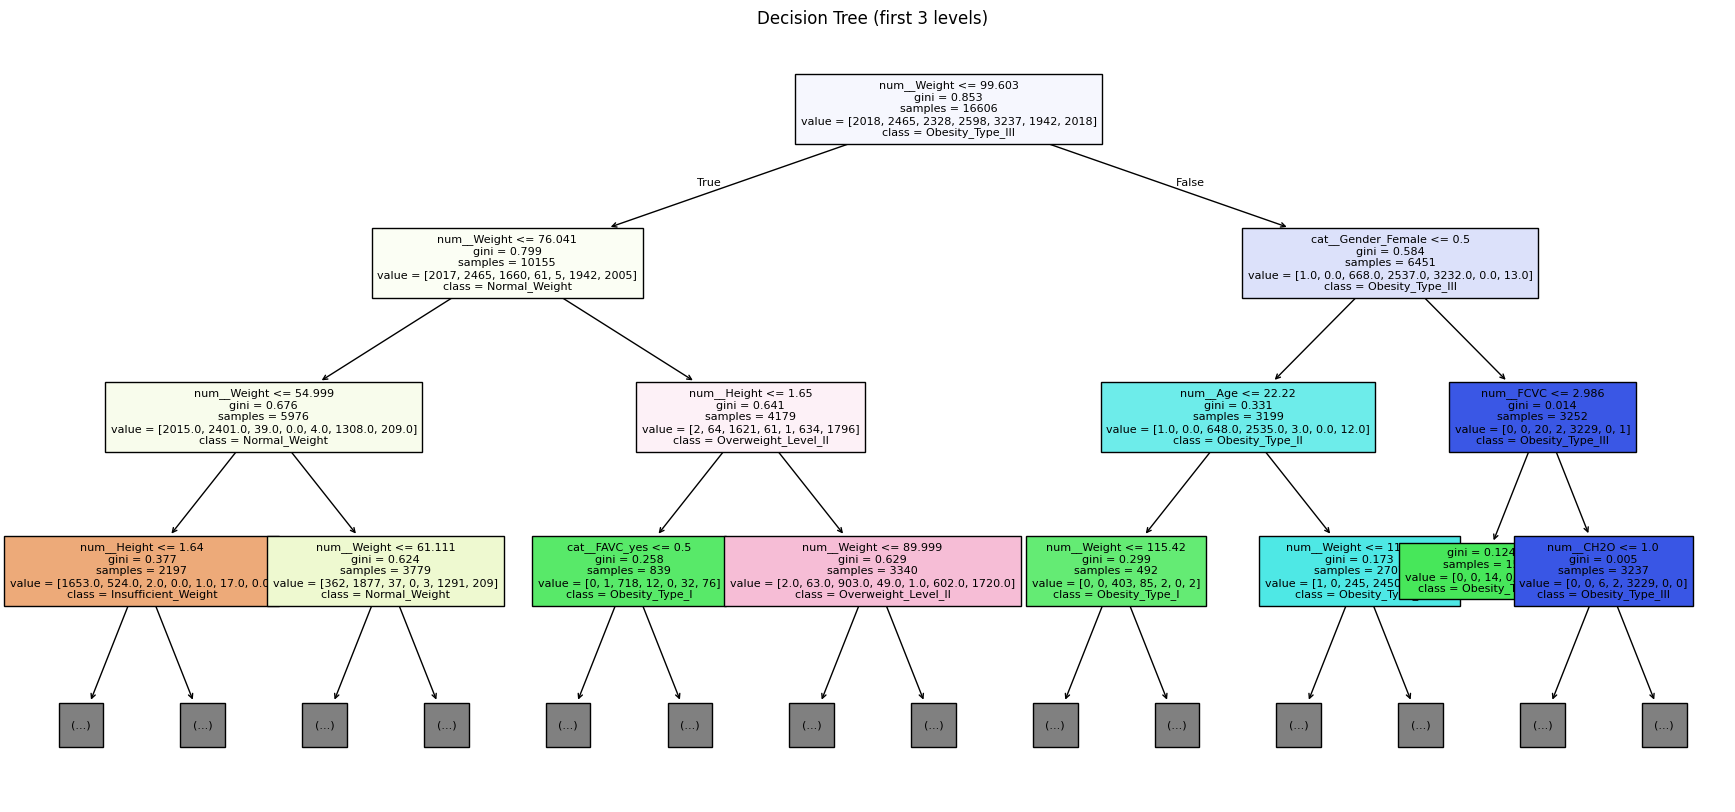

In [23]:
# Render the tree visualization
plt.figure(figsize=(22, 10))

# get the fitted tree classifier from the pipeline
tree_clf = dt_model.named_steps["classifier"]

# get transformed feature names after preprocessing
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=tree_clf.classes_,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree (first 3 levels)")
plt.show()

In [16]:
# Bagging model pipeline
bag_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=123),
        n_estimators=300,
        random_state=123,
        n_jobs=-1
    ))
])

bag_model.fit(X_train, y_train)
bag_valid_preds = bag_model.predict(X_valid)

bag_accuracy = accuracy_score(y_valid, bag_valid_preds)
print("Bagging Accuracy:", bag_accuracy)
print("\nClassification Report:")
print(classification_report(y_valid, bag_valid_preds))

Bagging Accuracy: 0.8935452793834296

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.94       505
      Normal_Weight       0.86      0.87      0.87       617
     Obesity_Type_I       0.86      0.87      0.87       582
    Obesity_Type_II       0.96      0.96      0.96       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.78      0.75      0.76       485
Overweight_Level_II       0.79      0.79      0.79       504

           accuracy                           0.89      4152
          macro avg       0.88      0.88      0.88      4152
       weighted avg       0.89      0.89      0.89      4152



In [17]:
# Random Forest model pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=123,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_valid_preds = rf_model.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, rf_valid_preds)
print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_valid, rf_valid_preds))

Random Forest Accuracy: 0.8952312138728323

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93       505
      Normal_Weight       0.84      0.88      0.86       617
     Obesity_Type_I       0.88      0.89      0.88       582
    Obesity_Type_II       0.97      0.96      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.80      0.71      0.76       485
Overweight_Level_II       0.78      0.81      0.80       504

           accuracy                           0.90      4152
          macro avg       0.88      0.88      0.88      4152
       weighted avg       0.89      0.90      0.89      4152



num__Weight                                0.351142
num__Age                                   0.087574
num__FCVC                                  0.081282
num__Height                                0.076940
cat__Gender_Female                         0.050057
cat__Gender_Male                           0.044659
num__CH2O                                  0.042002
num__TUE                                   0.038924
num__FAF                                   0.032672
num__NCP                                   0.027651
num__id                                    0.026408
cat__family_history_with_overweight_no     0.021619
cat__family_history_with_overweight_yes    0.019581
cat__CALC_Sometimes                        0.016042
cat__CAEC_Frequently                       0.014005
cat__CALC_no                               0.013530
cat__CAEC_Sometimes                        0.012711
cat__MTRANS_Public_Transportation          0.008876
cat__MTRANS_Automobile                     0.007447
cat__FAVC_ye

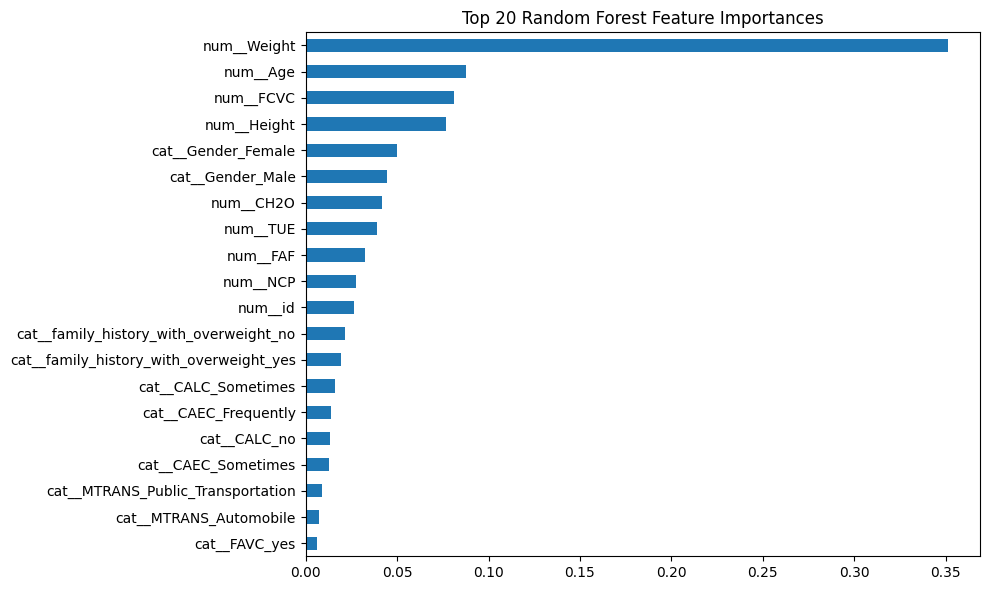

In [24]:
# Show feature importance for Random Forest
rf_clf = rf_model.named_steps["classifier"]
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

rf_importance = pd.Series(rf_clf.feature_importances_, index=rf_feature_names)
rf_importance = rf_importance.sort_values(ascending=False).head(20)

print(rf_importance)

plt.figure(figsize=(10, 6))
rf_importance.sort_values().plot(kind="barh")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show() 

In [18]:
# Boosting model pipeline
X_train_boost = pd.get_dummies(X_train, drop_first=False)
X_valid_boost = pd.get_dummies(X_valid, drop_first=False)
X_test_boost = pd.get_dummies(X_test_kaggle, drop_first=False)

X_valid_boost = X_valid_boost.reindex(columns=X_train_boost.columns, fill_value=0)
X_test_boost = X_test_boost.reindex(columns=X_train_boost.columns, fill_value=0)

boost_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=123
)

boost_model.fit(X_train_boost, y_train)
boost_valid_preds = boost_model.predict(X_valid_boost)

boost_accuracy = accuracy_score(y_valid, boost_valid_preds)
print("Boosting Accuracy:", boost_accuracy)
print("\nClassification Report:")
print(classification_report(y_valid, boost_valid_preds))

Boosting Accuracy: 0.9063102119460501

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.95      0.95       505
      Normal_Weight       0.87      0.89      0.88       617
     Obesity_Type_I       0.88      0.90      0.89       582
    Obesity_Type_II       0.97      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.82      0.75      0.78       485
Overweight_Level_II       0.80      0.81      0.80       504

           accuracy                           0.91      4152
          macro avg       0.90      0.90      0.90      4152
       weighted avg       0.91      0.91      0.91      4152



In [19]:
# Compare performance across models
results_df = pd.DataFrame({
    "Model": ["Decision Tree", "Bagging", "Random Forest", "Boosting"],
    "Validation Accuracy": [dt_accuracy, bag_accuracy, rf_accuracy, boost_accuracy]
}).sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Validation Accuracy
0,Boosting,0.906310
1,Random Forest,0.895231
2,Bagging,0.893545
3,Decision Tree,0.840318


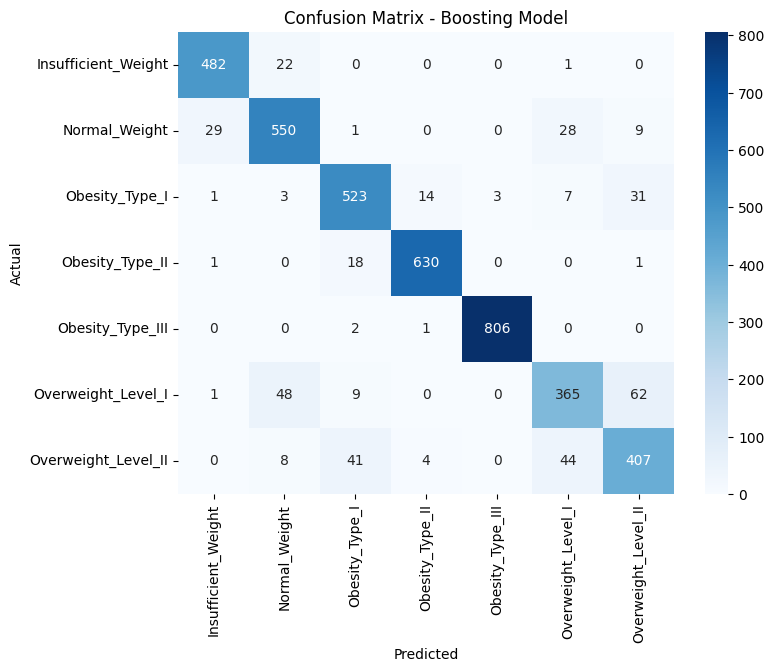

In [22]:
# Create confusion matrix for best model (Boosting)
import seaborn as sns

conf_matrix = confusion_matrix(y_valid, boost_valid_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=boost_model.classes_, yticklabels=boost_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Boosting Model")
plt.show()

In [25]:
# Complete predictions on test set for Kaggle submission

# Fit models on full training data
dt_model.fit(X, y)
bag_model.fit(X, y)
rf_model.fit(X, y)

X_full_boost = pd.get_dummies(X, drop_first=False)
X_test_boost_final = pd.get_dummies(X_test_kaggle, drop_first=False)
X_test_boost_final = X_test_boost_final.reindex(columns=X_full_boost.columns, fill_value=0)

boost_model.fit(X_full_boost, y)

# Generate predictions for test set
dt_test_preds = dt_model.predict(X_test_kaggle)
bag_test_preds = bag_model.predict(X_test_kaggle)
rf_test_preds = rf_model.predict(X_test_kaggle)
boost_test_preds = boost_model.predict(X_test_boost_final)

In [26]:
# Export submission files
dt_submission = pd.DataFrame({
    "id": test_df["id"],
    "NObeyesdad": dt_test_preds
})

bag_submission = pd.DataFrame({
    "id": test_df["id"],
    "NObeyesdad": bag_test_preds
})

rf_submission = pd.DataFrame({
    "id": test_df["id"],
    "NObeyesdad": rf_test_preds
})

boost_submission = pd.DataFrame({
    "id": test_df["id"],
    "NObeyesdad": boost_test_preds
})

dt_submission.to_csv("submission_decision_tree.csv", index=False)
bag_submission.to_csv("submission_bagging.csv", index=False)
rf_submission.to_csv("submission_random_forest.csv", index=False)
boost_submission.to_csv("submission_boosting.csv", index=False)